<a href="https://colab.research.google.com/github/Gabriel-idkw/Customer-Behavior-Prediction/blob/main/04_dbscan_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 — DBSCAN Clustering
### Grid Search, Metrics, Visualization

Loads the shared baseline from Notebook 01. Independent of Notebooks 02/03. Exports `models/dbscan_model.pkl` and `metrics/dbscan_results.json`.

DBSCAN has no `K` to choose — instead it needs `eps` (neighborhood radius) and `min_samples` (density threshold) tuned, and it can label points as **noise** (`-1`) instead of forcing every point into a cluster. We report the noise percentage explicitly, since that's the key DBSCAN diagnostic alongside silhouette.

In [10]:
from google.colab import drive
drive.mount('/content/drive')

import os, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

sns.set_style('whitegrid')
RANDOM_STATE = 42
PROJECT_ROOT = '/content/drive/MyDrive/customer-segmentation-ml'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Load the shared baseline

In [11]:
X_df = pd.read_csv(f'{PROJECT_ROOT}/data/preprocessed_rfm_scaled.csv')
customer_ids = X_df['Customer ID']
X = X_df.drop(columns=['Customer ID']).values
raw_df = pd.read_csv(f'{PROJECT_ROOT}/data/customer_features_raw.csv')

print('X shape:', X.shape)


X shape: (49661, 16)


## 2. k-distance plot (to sanity-check the `eps` search range)

Standard DBSCAN diagnostic: sort each point's distance to its `k`-th nearest neighbor and plot it. The "knee" of this curve is a good candidate `eps`. We use it here to justify the grid search range below rather than picking `eps` values arbitrarily.

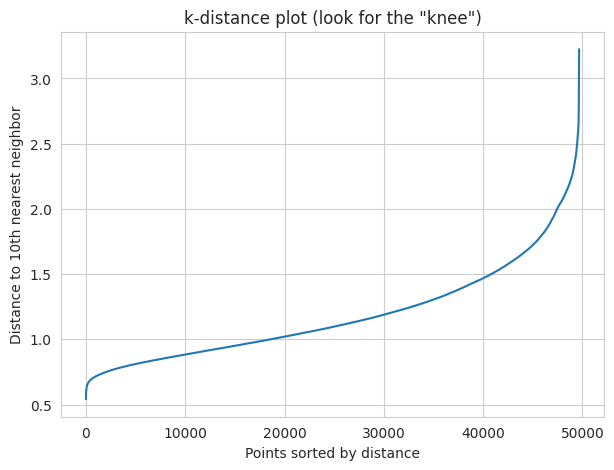

In [12]:
MIN_SAMPLES_FOR_KDIST = 10
nbrs = NearestNeighbors(n_neighbors=MIN_SAMPLES_FOR_KDIST).fit(X)
distances, _ = nbrs.kneighbors(X)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(7, 5))
plt.plot(k_distances)
plt.xlabel('Points sorted by distance')
plt.ylabel(f'Distance to {MIN_SAMPLES_FOR_KDIST}th nearest neighbor')
plt.title('k-distance plot (look for the "knee")')
plt.show()


## 3. Grid search

Sweep `eps` and `min_samples`. Silhouette is computed **excluding noise points** and on a 5,000-point sample for the same `O(n²)` reason noted in Notebook 02; Davies-Bouldin/Calinski-Harabasz are computed on the full non-noise set. Combinations that produce fewer than 2 clusters, or where every point is noise, are skipped.

In [14]:
eps_options = [0.5, 0.8, 1.0, 1.5, 2.0, 2.5]
min_samples_options = [5, 10, 15, 20]
SIL_SAMPLE_SIZE = 5000
rng = np.random.RandomState(RANDOM_STATE)

grid_results = []
for eps in eps_options:
    for min_samples in min_samples_options:
        labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        noise_pct = float((labels == -1).mean() * 100)

        if n_clusters < 2:
            grid_results.append({'eps': eps, 'min_samples': min_samples, 'n_clusters': n_clusters,
                                  'noise_pct': noise_pct, 'silhouette': None, 'davies_bouldin': None,
                                  'calinski_harabasz': None})
            continue

        mask = labels != -1
        X_valid, labels_valid = X[mask], labels[mask]

        sample_size = min(SIL_SAMPLE_SIZE, len(X_valid))
        sample_idx = rng.choice(len(X_valid), size=sample_size, replace=False)
        sil = silhouette_score(X_valid[sample_idx], labels_valid[sample_idx])
        db = davies_bouldin_score(X_valid, labels_valid)
        ch = calinski_harabasz_score(X_valid, labels_valid)

        grid_results.append({
            'eps': eps, 'min_samples': min_samples, 'n_clusters': n_clusters,
            'noise_pct': noise_pct, 'silhouette': float(sil),
            'davies_bouldin': float(db), 'calinski_harabasz': float(ch),
        })

results_df = pd.DataFrame(grid_results)
results_df.sort_values('silhouette', ascending=False, na_position='last').head(10)


,eps,min_samples,n_clusters,noise_pct,silhouette,davies_bouldin,calinski_harabasz
0,0.5,5,91,98.920682,0.530093,0.642689,125.559159
16,2.0,5,13,0.692696,0.398968,1.075992,41.508709
18,2.0,15,2,2.738567,0.350599,0.774833,75.101114
17,2.0,10,3,1.848533,0.311971,0.719368,24.097373
12,1.5,5,27,6.552425,0.183779,0.939983,20.628872
14,1.5,15,3,10.984475,0.153388,0.872193,19.417926
7,0.8,20,30,94.855118,0.120505,1.365687,113.565293
11,1.0,20,27,57.375003,0.072173,2.192973,519.494215
10,1.0,15,32,50.202372,0.054000,2.106060,482.435152
6,0.8,15,57,88.040917,0.016371,1.424115,119.980356


## 4. Silhouette vs. `eps`, by `min_samples`

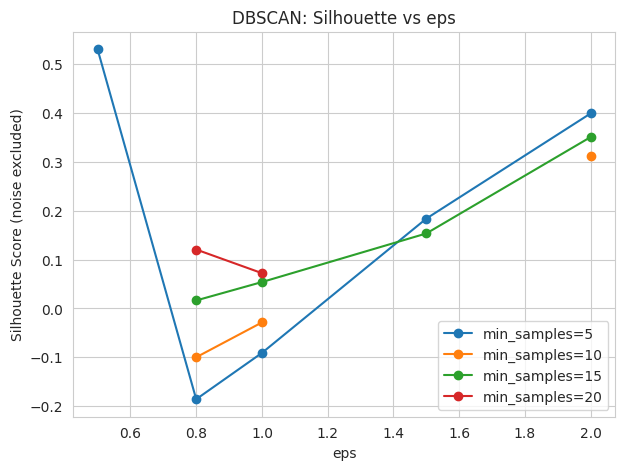

In [15]:
plt.figure(figsize=(7, 5))
for ms in min_samples_options:
    sl = results_df[results_df['min_samples'] == ms].sort_values('eps')
    plt.plot(sl['eps'], sl['silhouette'], marker='o', label=f'min_samples={ms}')
plt.xlabel('eps')
plt.ylabel('Silhouette Score (noise excluded)')
plt.title('DBSCAN: Silhouette vs eps')
plt.legend()
plt.show()


## 5. Pick the best configuration and refit

In [16]:
valid_results = results_df.dropna(subset=['silhouette'])
best_row = valid_results.sort_values('silhouette', ascending=False).iloc[0]
BEST_EPS = float(best_row['eps'])
BEST_MIN_SAMPLES = int(best_row['min_samples'])

print('Best config by silhouette:')
print(best_row)

final_model = DBSCAN(eps=BEST_EPS, min_samples=BEST_MIN_SAMPLES)
final_labels = final_model.fit_predict(X)
noise_pct_final = float((final_labels == -1).mean() * 100)
print(f'Noise: {noise_pct_final:.2f}% | Clusters found: {len(set(final_labels)) - (1 if -1 in final_labels else 0)}')


Best config by silhouette:
eps                    0.500000
min_samples            5.000000
n_clusters            91.000000
noise_pct             98.920682
silhouette             0.530093
davies_bouldin         0.642689
calinski_harabasz    125.559159
Name: 0, dtype: float64
Noise: 98.92% | Clusters found: 91


## 6. 2D PCA scatter (noise shown separately)

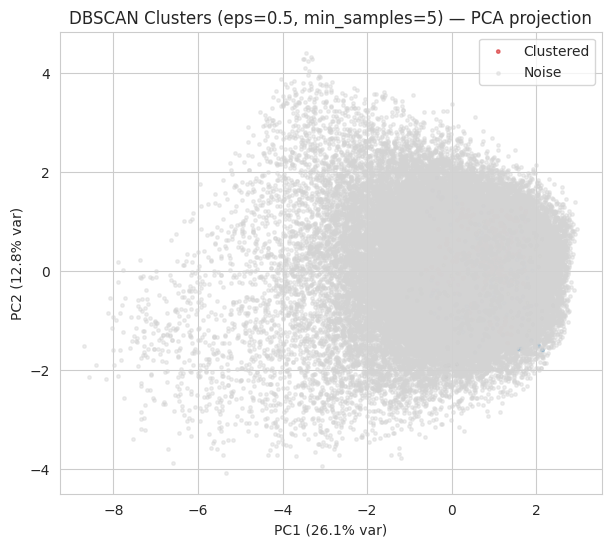

In [17]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(7, 6))
is_noise = final_labels == -1
plt.scatter(X_pca[~is_noise, 0], X_pca[~is_noise, 1], c=final_labels[~is_noise], cmap='tab10', s=6, alpha=0.6, label='Clustered')
plt.scatter(X_pca[is_noise, 0], X_pca[is_noise, 1], c='lightgray', s=6, alpha=0.4, label='Noise')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
plt.title(f'DBSCAN Clusters (eps={BEST_EPS}, min_samples={BEST_MIN_SAMPLES}) — PCA projection')
plt.legend()
plt.show()


## 7. Cluster profile (real units, noise excluded)

In [18]:
profile_df = raw_df.copy()
profile_df['cluster'] = final_labels
profile_df_valid = profile_df[profile_df['cluster'] != -1]

display_cols = ['recency_days', 'frequency', 'monetary_total', 'monetary_avg', 'return_rate', 'churn']
cluster_profile = profile_df_valid.groupby('cluster')[display_cols].mean().round(2)
cluster_profile['n_customers'] = profile_df_valid.groupby('cluster').size()
cluster_profile


,recency_days,frequency,monetary_total,monetary_avg,return_rate,churn,n_customers
cluster,,,,,,,
0,64.00,6.00,14464.62,2410.77,33.33,0.25,8
1,105.67,6.00,14785.67,2464.28,16.67,0.00,6
2,149.57,5.00,13550.00,2710.00,60.00,0.14,7
3,188.80,4.00,12568.80,3142.20,25.00,0.20,5
4,184.20,6.00,16926.40,2821.07,50.00,0.20,5
...,...,...,...,...,...,...,...
86,199.60,3.00,11764.80,3921.60,66.67,0.40,5
87,66.00,7.25,22951.50,3174.20,27.68,0.25,4
88,115.20,5.00,12762.00,2552.40,40.00,0.00,5


## 8. Export

DBSCAN has no native `.predict()` for new points (only `fit_predict` on the data it was fit on) — we still save the fitted object for reference, but as the guide notes, KMeans is the model that gets deployed.

In [19]:
joblib.dump(final_model, f'{PROJECT_ROOT}/models/dbscan_model.pkl')

dbscan_results = {
    'algorithm': 'DBSCAN',
    'grid_search': grid_results,
    'best_params': {'eps': BEST_EPS, 'min_samples': BEST_MIN_SAMPLES},
    'best_metrics': {
        'silhouette': float(best_row['silhouette']),
        'davies_bouldin': float(best_row['davies_bouldin']),
        'calinski_harabasz': float(best_row['calinski_harabasz']),
        'noise_pct': noise_pct_final,
    },
    'n_clusters_found': int(len(set(final_labels)) - (1 if -1 in final_labels else 0)),
    'notes': 'No native .predict() for new data; finds outliers as noise (-1) rather than forcing every customer into a cluster.',
}
with open(f'{PROJECT_ROOT}/metrics/dbscan_results.json', 'w') as f:
    json.dump(dbscan_results, f, indent=2)

print('Saved models/dbscan_model.pkl and metrics/dbscan_results.json')
print(json.dumps(dbscan_results['best_params'], indent=2))
print(json.dumps(dbscan_results['best_metrics'], indent=2))


Saved models/dbscan_model.pkl and metrics/dbscan_results.json
{
  "eps": 0.5,
  "min_samples": 5
}
{
  "silhouette": 0.5300931582422727,
  "davies_bouldin": 0.6426888088931669,
  "calinski_harabasz": 125.5591587581769,
  "noise_pct": 98.9206822254888
}
